In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
#demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/VIC_clean.csv")
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/master_data.csv")

demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")


df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y/%m/%d %H:%M")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Extract year column
df['Year'] = df['Datetime'].dt.year

df['Day'] = df['Datetime'].dt.day_name()



CSV files loaded


In [2]:
# Start making model for the graph above

# Data Seperation as X and Y

x = df[['Datetime']].copy()
x['month'] = x['Datetime'].dt.month
x = x[['month']]  # keep only hour as feature

y = df['Total Demand']

#Data splitting

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=100)


#print(len(X_train)) # 80% of data size

#print(len(X_test)) # 20% of data size

#print(len(x)) # Original Data size


In [3]:
# Model Building with Random forest

# Training the model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, Y_train)

# Applying the model to make a prediction

y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

# Model performance
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(Y_train, y_rf_train_pred)
rf_train_r2 = r2_score(Y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(Y_test, y_rf_test_pred)
rf_test_r2 = r2_score(Y_test, y_rf_test_pred)

plot_df = pd.DataFrame({
    "Month": X_test.values.flatten(),
    "Predicted_Demand": y_rf_test_pred
})

rf_results = pd.DataFrame(["Random forest", rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ["Method", "Training MSE", "Training R2", "Test MSE", "Test R2"]
print(rf_results)


          Method   Training MSE Training R2       Test MSE   Test R2
0  Random forest  728939.345796    0.073393  730457.640747  0.076968


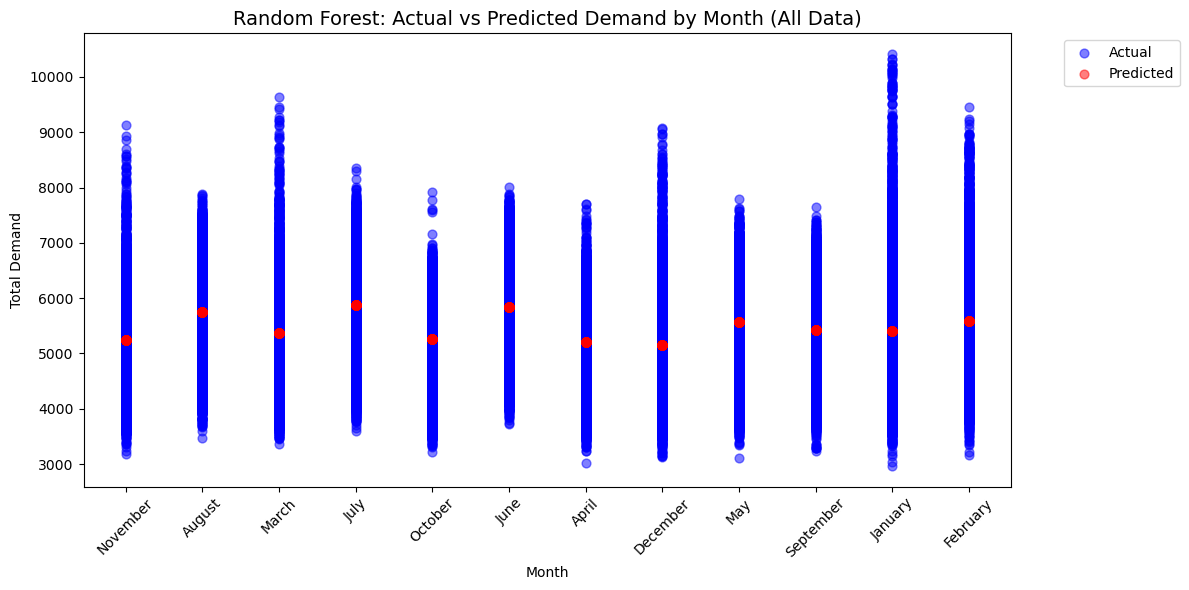

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Build a DataFrame with actual vs predicted
plot_df = pd.DataFrame({
    "Month": X_test.values.flatten(),
    "Actual_Demand": Y_test.values.flatten(),
    "Predicted_Demand": y_rf_test_pred
})

# ✅ If X_test has numeric months, map them to month names
month_map = {1:"January", 2:"February", 3:"March", 4:"April", 5:"May", 6:"June",
             7:"July", 8:"August", 9:"September", 10:"October", 11:"November", 12:"December"}
plot_df["Month"] = plot_df["Month"].map(month_map)

# Plot
plt.figure(figsize=(12, 6))

# Scatter plot of all actual values
plt.scatter(plot_df["Month"], plot_df["Actual_Demand"], 
            color="blue", s=40, alpha=0.5, label="Actual")

# Scatter plot of all predicted values
plt.scatter(plot_df["Month"], plot_df["Predicted_Demand"], 
            color="red", s=40, alpha=0.5, label="Predicted")

# Title & labels
plt.title("Random Forest: Actual vs Predicted Demand by Month (All Data)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)

# Legend
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


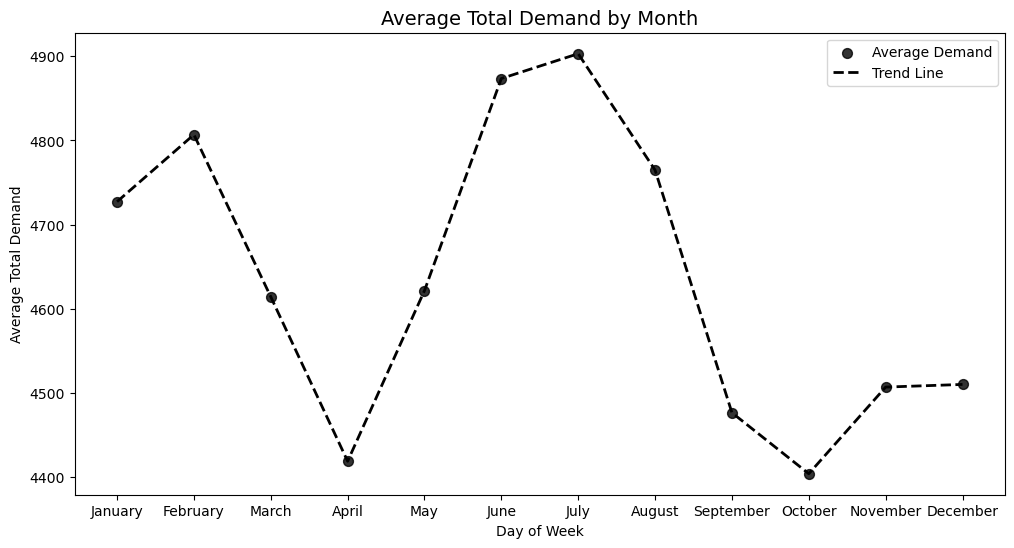

Average Total Demand by Month
Month
January      4727.23
February     4806.93
March        4614.12
April        4418.69
May          4621.54
June         4873.64
July         4903.10
August       4764.77
September    4476.40
October      4403.85
November     4506.83
December     4509.98
Name: Total Demand, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import pandas as pd


df['Month'] = df['Datetime'].dt.month_name()
# Define the correct order of days
day_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
#day_order = ['September', 'October', 'November', 'December', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', ]

# Calculate average total demand for each day
average_demand_by_month = df.groupby('Month')['Total Demand'].mean()

# Reindex to ensure days are ordered from Monday to Sunday
average_demand_by_month = average_demand_by_month.reindex(day_order)

# Create scatter plot with a connecting line
plt.figure(figsize=(12, 6))
plt.scatter(average_demand_by_month.index, average_demand_by_month.values, 
            color='black', s=50, alpha=0.8, label='Average Demand')
plt.plot(average_demand_by_month.index, average_demand_by_month.values, 
         color='black', linewidth=2, linestyle='--', label='Trend Line')

# Update title and labels
plt.title("Average Total Demand by Month", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Total Demand")
plt.legend()

# Show plot
plt.show()

# Print the averages
print("Average Total Demand by Month")
print(average_demand_by_month.round(2))


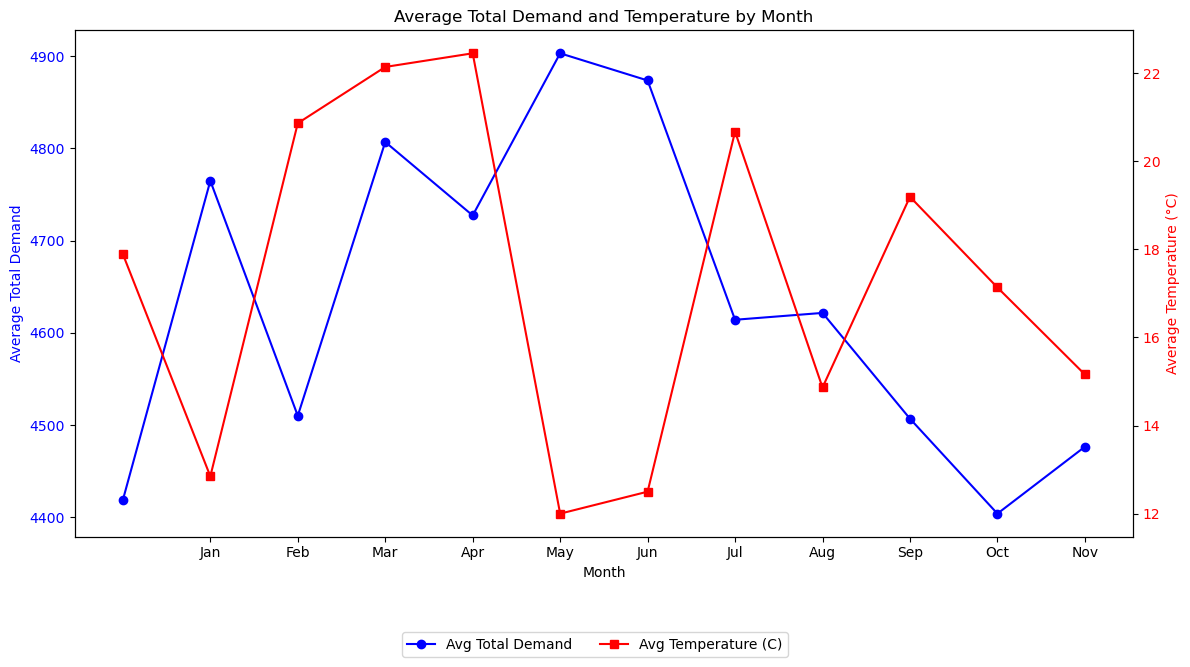

In [4]:
avg_tem = df.groupby('Month').agg({'Total Demand': 'mean', 'Air Temp (C)': 'mean'}).reset_index()
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Average Total Demand
ax1.plot(avg_tem['Month'], avg_tem['Total Demand'], color='blue', marker='o', label='Avg Total Demand')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Total Demand', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(1, 13))  # Assuming months 1-12
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Create a second y-axis for Average Temperature
ax2 = ax1.twinx()
ax2.plot(avg_tem['Month'], avg_tem['Air Temp (C)'], color='red', marker='s', label='Avg Temperature (C)')
ax2.set_ylabel('Average Temperature (°C)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add title and legend
plt.title('Average Total Demand and Temperature by Month')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show plot
plt.show()

